#### Load Attack Results

In [1]:
import json
import random
import re

import torch
import torchvision
import torchvision.transforms as T
import torch.nn.functional as F
from torch.utils.data import DataLoader

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from models import MNIST_Net, CIFAR_Net

device = "cuda" if torch.cuda.is_available() else "cpu"
sns.set(style="whitegrid")

with open("./results/attack_success_rate.json", "r") as f:
    data = json.load(f)

#### Load Dataset and Pretrained Model

In [2]:
def get_dataset_and_model(name):
    if name == "MNIST":
        dataset = torchvision.datasets.MNIST(
            root="./data",
            train=False,
            download=True,
            transform=T.ToTensor()
        )
        model = MNIST_Net().to(device)
        model.load_state_dict(torch.load("./ckpt/mnist.pth", map_location=device))
        model.eval()

    elif name == "CIFAR10":
        dataset = torchvision.datasets.CIFAR10(
            root="./data",
            train=False,
            download=True,
            transform=T.ToTensor()
        )
        model = CIFAR_Net().to(device)
        model.load_state_dict(torch.load("./ckpt/cifar.pth", map_location=device))
        model.eval()

    else:
        raise ValueError(f"Unsupported dataset name: {name}")

    return dataset, model

#### Parse Attack Results into DataFrame

In [3]:
def parse_attack_rows(data):
    rows = []

    for d in data:
        dataset = d["dataset"]
        loss = d.get("loss_func", d.get("loss", "unknown"))
        eps = d["eps"]

        for key, value in d.items():
            if key in ["dataset", "loss_func", "loss", "eps"]:
                continue

            if not isinstance(value, (int, float)):
                continue

            attack_type = "Targeted" if "Targeted" in key else "Untargeted"

            if "FGSM" in key:
                method = "FGSM"
                steps = 1

            elif "PGD" in key:
                method = "PGD"
                match = re.search(r"steps=(\d+)", key)
                steps = int(match.group(1)) if match else None
            else:
                continue

            rows.append({
                "dataset": dataset,
                "loss": loss,
                "eps": eps,
                "attack": key,
                "method": method,
                "attack_type": attack_type,
                "steps": steps,
                "attack_success_rate": value
            })

    return pd.DataFrame(rows)

In [4]:
df = parse_attack_rows(data)
df = df.sort_values(by=["dataset", "loss", "attack_type", "method", "eps", "steps"])
df.head()

,dataset,loss,eps,attack,method,attack_type,steps,attack_success_rate
14,cifar10,ce,0.0001,FGSM Targeted,FGSM,Targeted,1,0.016406
126,cifar10,ce,0.0010,FGSM Targeted,FGSM,Targeted,1,0.041094
238,cifar10,ce,0.0100,FGSM Targeted,FGSM,Targeted,1,0.339062
350,cifar10,ce,0.0300,FGSM Targeted,FGSM,Targeted,1,0.355781
462,cifar10,ce,0.0500,FGSM Targeted,FGSM,Targeted,1,0.293906


#### Compute Input Gradient Magnitude

In [5]:
def compute_gradient_norm(model, x, y, loss_type):
    x = x.clone().detach().to(device)
    x.requires_grad = True
    y = y.to(device)

    logits = model(x)

    if loss_type == "ce":
        loss = F.cross_entropy(logits, y)

    elif loss_type == "mse":
        one_hot = F.one_hot(y, num_classes=logits.shape[1]).float()
        loss = F.mse_loss(F.softmax(logits, dim=1), one_hot)

    elif loss_type == "kl":
        one_hot = F.one_hot(y, num_classes=logits.shape[1]).float()
        loss = F.kl_div(F.log_softmax(logits, dim=1), one_hot, reduction="batchmean")

    elif loss_type == "margin":
        correct = logits.gather(1, y.unsqueeze(1)).squeeze()
        top2 = logits.topk(2, dim=1).values
        wrong = top2[:, 1]
        loss = -(correct - wrong).mean()

    else:
        raise ValueError(f"Unsupported loss type: {loss_type}")

    loss.backward()
    return x.grad.abs().mean().item()

#### Compute PGD Statistics (Gain, Efficiency, Saturation)

In [6]:
# Compute PGD Statistics (Gain, Efficiency, Saturation)

def add_pgd_statistics(df):
    pgd_df = df[df["method"] == "PGD"].copy()
    pgd_df = pgd_df.sort_values(
        by=["dataset","loss","attack_type","eps","steps"]
    )

    pgd_df["gain"] = pgd_df.groupby(
        ["dataset","loss","attack_type","eps"]
    )["attack_success_rate"].diff()

    pgd_df["efficiency"] = pgd_df["attack_success_rate"] / pgd_df["steps"]
    pgd_df["saturated"] = pgd_df["gain"] < 0.01

    return pgd_df

pgd_df = add_pgd_statistics(df)
pgd_df.head()

,dataset,loss,eps,attack,method,attack_type,steps,attack_success_rate,gain,efficiency,saturated
16,cifar10,ce,0.0001,PGD Targeted (steps=10),PGD,Targeted,10,0.016719,NaN,0.001672,False
18,cifar10,ce,0.0001,PGD Targeted (steps=20),PGD,Targeted,20,0.017031,0.000313,0.000852,True
20,cifar10,ce,0.0001,PGD Targeted (steps=30),PGD,Targeted,30,0.012656,-0.004375,0.000422,True
22,cifar10,ce,0.0001,PGD Targeted (steps=40),PGD,Targeted,40,0.017656,0.005000,0.000441,True
24,cifar10,ce,0.0001,PGD Targeted (steps=50),PGD,Targeted,50,0.015469,-0.002187,0.000309,True


## MNIST

In [7]:
mnist_df = df[df["dataset"] == "mnist"].copy()
mnist_df.head()

,dataset,loss,eps,attack,method,attack_type,steps,attack_success_rate
0,mnist,ce,0.0001,FGSM Targeted,FGSM,Targeted,1,0.000625
112,mnist,ce,0.0010,FGSM Targeted,FGSM,Targeted,1,0.002969
224,mnist,ce,0.0100,FGSM Targeted,FGSM,Targeted,1,0.002500
336,mnist,ce,0.0300,FGSM Targeted,FGSM,Targeted,1,0.003438
448,mnist,ce,0.0500,FGSM Targeted,FGSM,Targeted,1,0.006875


#### MNIST: Attack Success Rate vs Epsilon

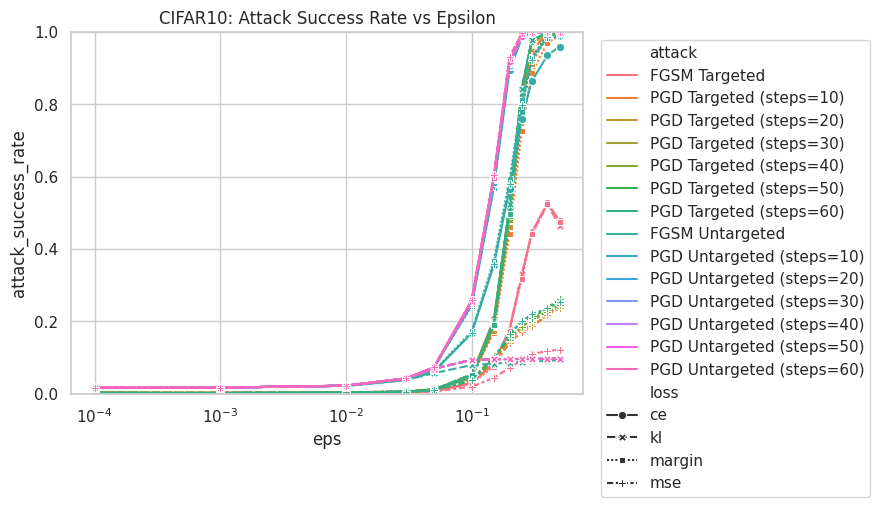

In [8]:
plt.figure(figsize=(9,5))
sns.lineplot(
    data=mnist_df,
    x="eps",
    y="attack_success_rate",
    hue="attack",
    style="loss",
    markers=True
)
plt.xscale("log")
plt.ylim(0,1)
plt.title("CIFAR10: Attack Success Rate vs Epsilon")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

#### MNIST: Average Attack Success by Loss Function

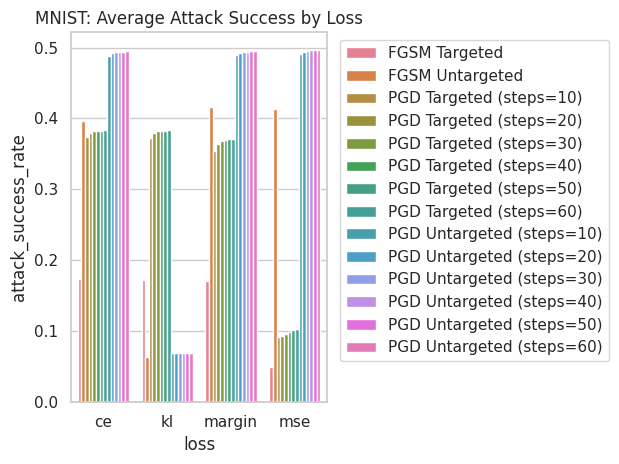

In [9]:
mnist_group = mnist_df.groupby(["loss","attack"])["attack_success_rate"].mean().reset_index()

sns.barplot(data=mnist_group, x="loss", y="attack_success_rate", hue="attack")
plt.title("MNIST: Average Attack Success by Loss")

plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

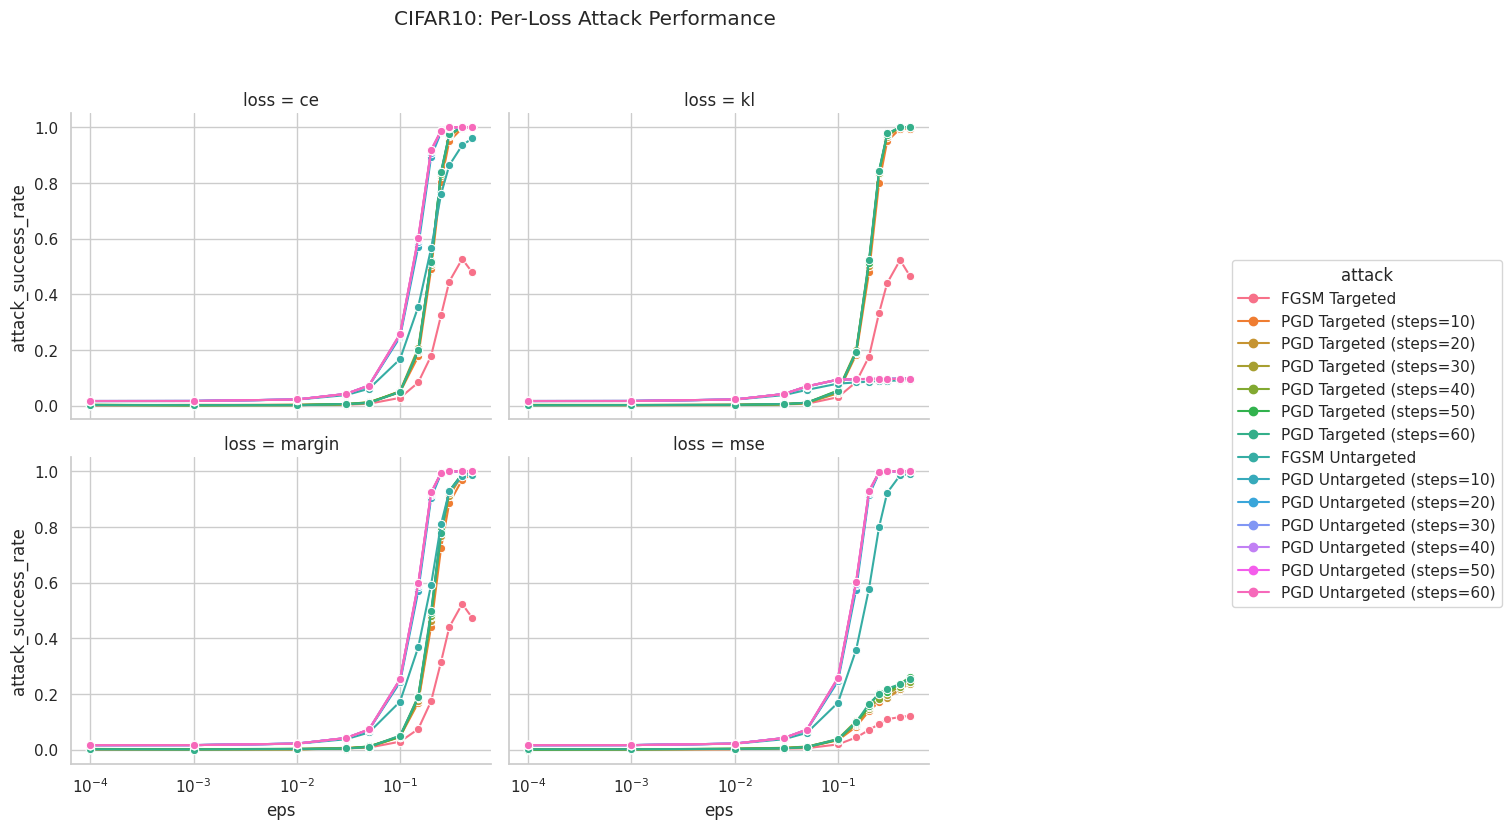

In [10]:
g = sns.relplot(
    data=mnist_df,
    x="eps",
    y="attack_success_rate",
    hue="attack",
    col="loss",
    kind="line",
    marker="o",
    col_wrap=2,
    height=4,
    aspect=1.2,
    legend="full"
)

g.set(xscale="log")
g.fig.suptitle("CIFAR10: Per-Loss Attack Performance", y=1.03)

sns.move_legend(
    g,
    "center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

g.fig.subplots_adjust(right=0.78, top=0.90)

plt.show()

#### MNIST: PGD Success Rate vs Iterations

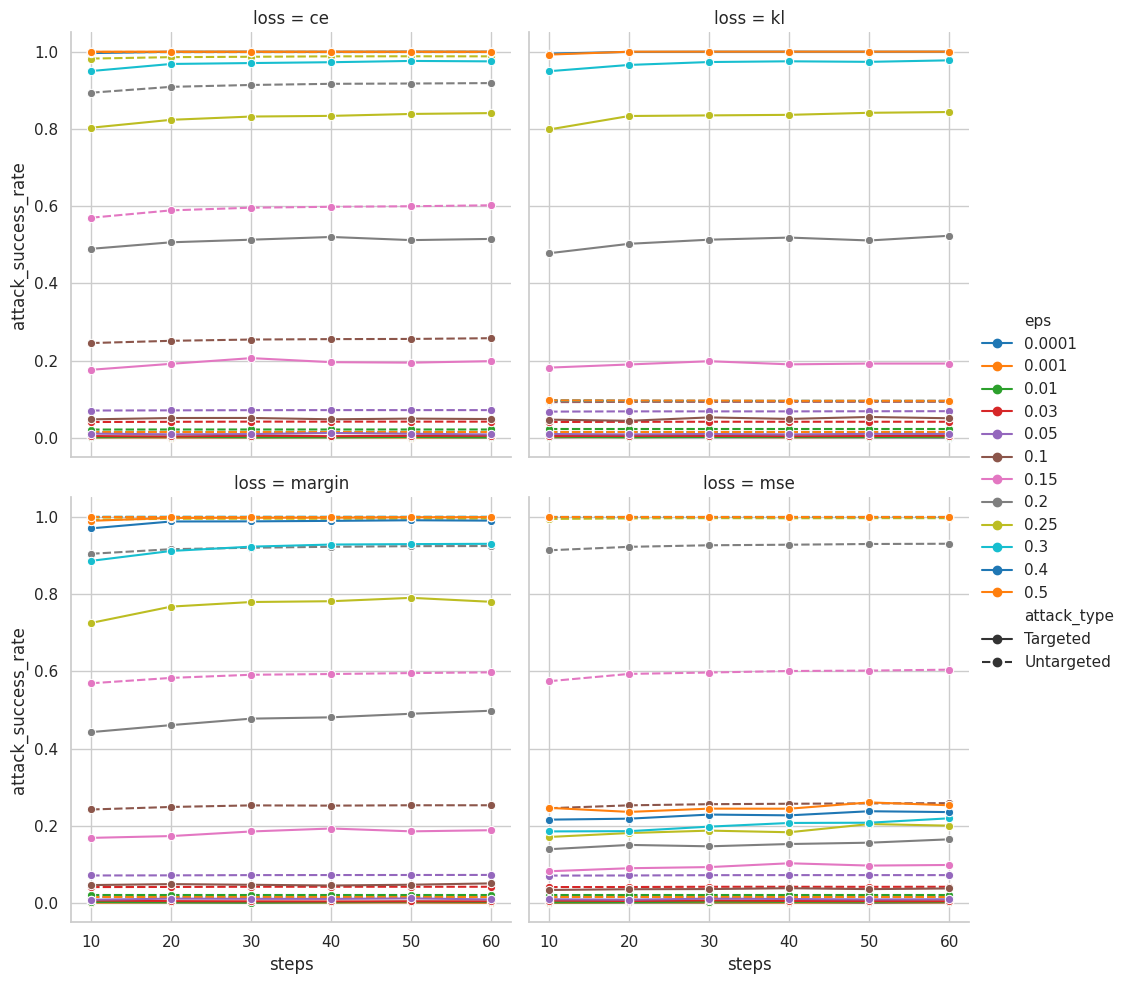

In [44]:
mnist_pgd_df = pgd_df[pgd_df["dataset"]=="mnist"]

sns.relplot(
    data=mnist_pgd_df,
    x="steps",
    y="attack_success_rate",
    hue="eps",
    style="attack_type",
    col="loss",
    kind="line",
    marker="o",
    col_wrap=2,
    palette="tab10",
    legend="full"
)
plt.show()

#### MNIST: PGD Gain per Iteration

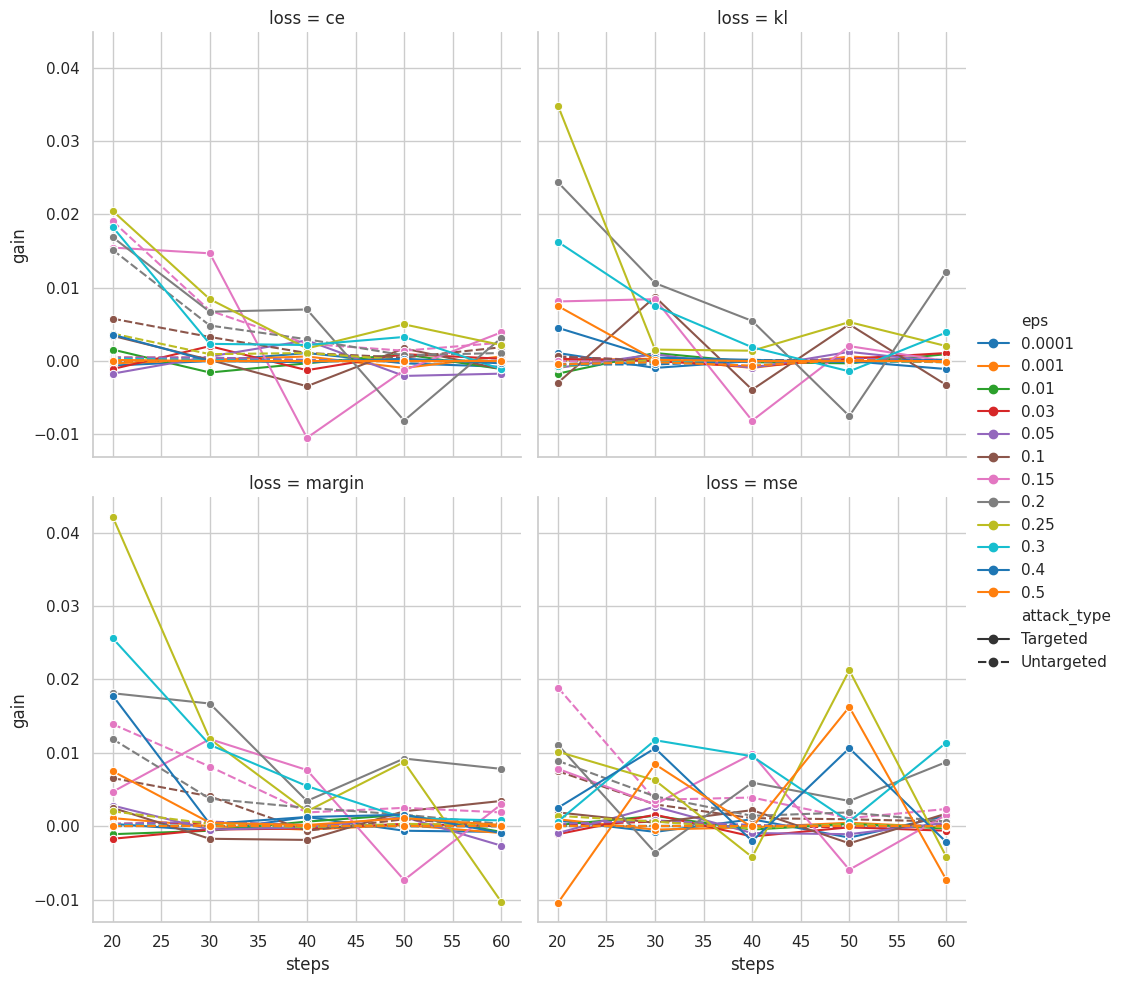

In [43]:
sns.relplot(
    data=mnist_pgd_df,
    x="steps",
    y="gain",
    hue="eps",
    style="attack_type",
    col="loss",
    kind="line",
    marker="o",
    col_wrap=2,
    palette="tab10",
    legend="full"
)
plt.show()

#### MNIST: PGD Efficiency

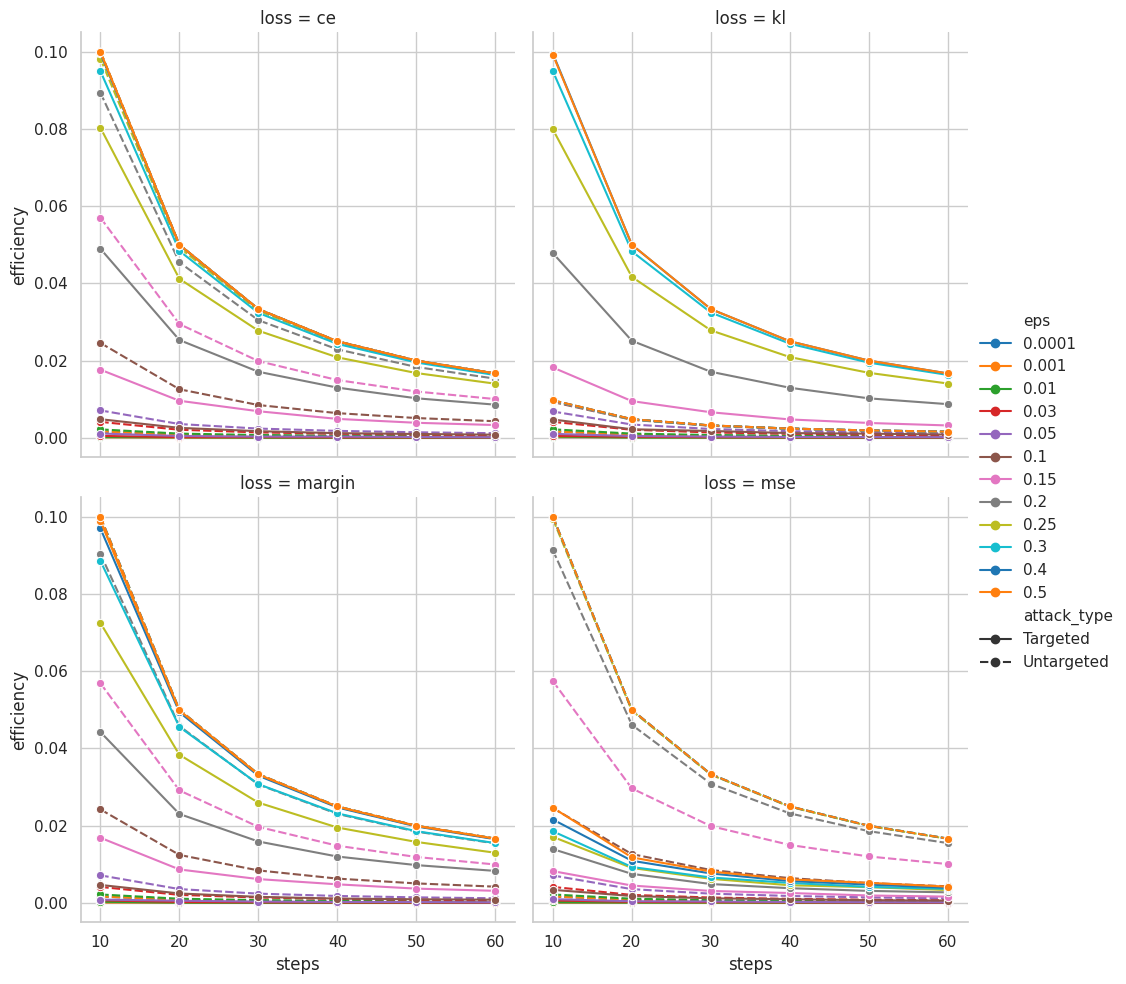

In [42]:
sns.relplot(
    data=mnist_pgd_df,
    x="steps",
    y="efficiency",
    hue="eps",
    style="attack_type",
    col="loss",
    kind="line",
    marker="o",
    col_wrap=2,
    palette="tab10",
    legend="full"
)
plt.show()

#### MNIST: Saturation Point Analysis

In [14]:
mnist_sat = mnist_pgd_df[mnist_pgd_df["saturated"]==True]

mnist_sat.groupby(["loss","attack_type","eps"])["steps"].min().reset_index()

,loss,attack_type,eps,steps
0,ce,Targeted,0.0001,20
1,ce,Targeted,0.0010,20
2,ce,Targeted,0.0100,20
3,ce,Targeted,0.0300,20
4,ce,Targeted,0.0500,20
...,...,...,...,...
91,mse,Untargeted,0.2000,20
92,mse,Untargeted,0.2500,20
93,mse,Untargeted,0.3000,20
94,mse,Untargeted,0.4000,20


#### MNIST: Gradient Magnitude

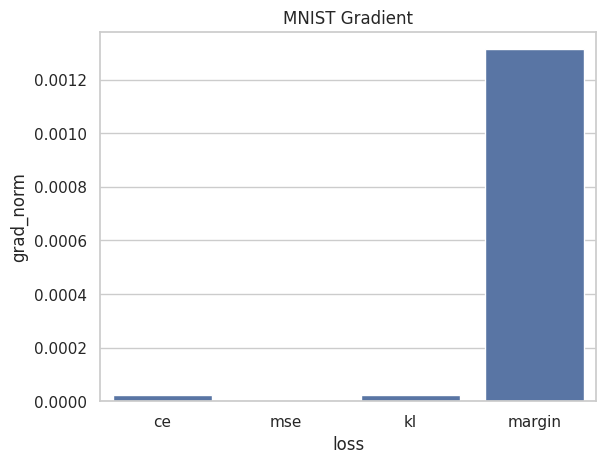

In [15]:
dataset, model = get_dataset_and_model("MNIST")
loader = DataLoader(dataset, batch_size=128)

results = []

for loss in ["ce","mse","kl","margin"]:
    vals = []
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        model.zero_grad()
        vals.append(compute_gradient_norm(model,x,y,loss))

    results.append({"loss":loss, "grad_norm":sum(vals)/len(vals)})

sns.barplot(data=pd.DataFrame(results), x="loss", y="grad_norm")
plt.title("MNIST Gradient")
plt.show()

## CIFAR10

In [16]:
cifar_df = df[df["dataset"] == "cifar10"].copy()

#### CIFAR10: Attack Success Rate vs Epsilon

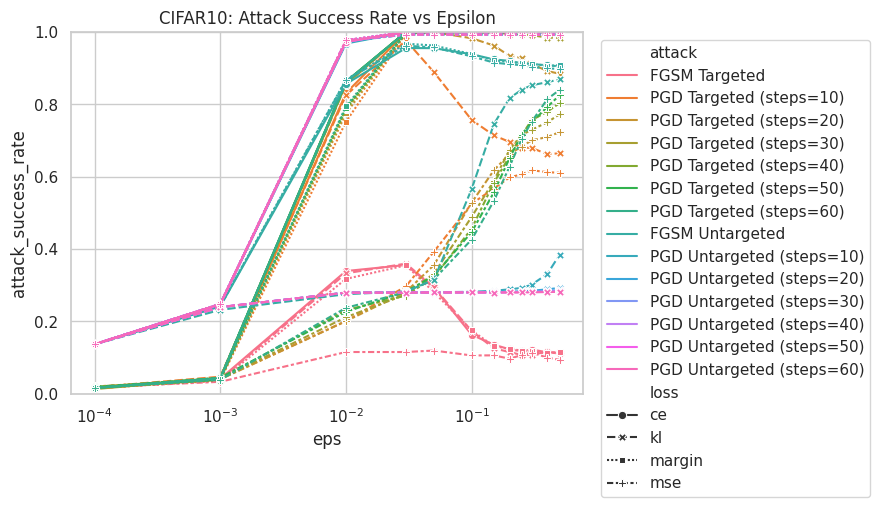

In [17]:
plt.figure(figsize=(9,5))
sns.lineplot(
    data=cifar_df,
    x="eps",
    y="attack_success_rate",
    hue="attack",
    style="loss",
    markers=True
)
plt.xscale("log")
plt.ylim(0,1)
plt.title("CIFAR10: Attack Success Rate vs Epsilon")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

#### CIFAR10: Average Attack Success by Loss Function

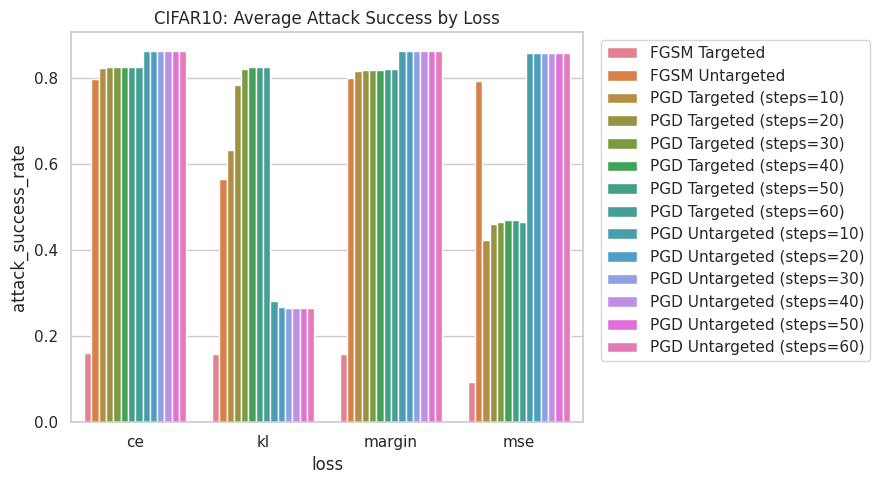

In [18]:
cifar_group = cifar_df.groupby(["loss","attack"])["attack_success_rate"].mean().reset_index()

plt.figure(figsize=(9,5))
sns.barplot(data=cifar_group, x="loss", y="attack_success_rate", hue="attack")
plt.title("CIFAR10: Average Attack Success by Loss")

plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

#### CIFAR10: Per-Loss Attack Performance

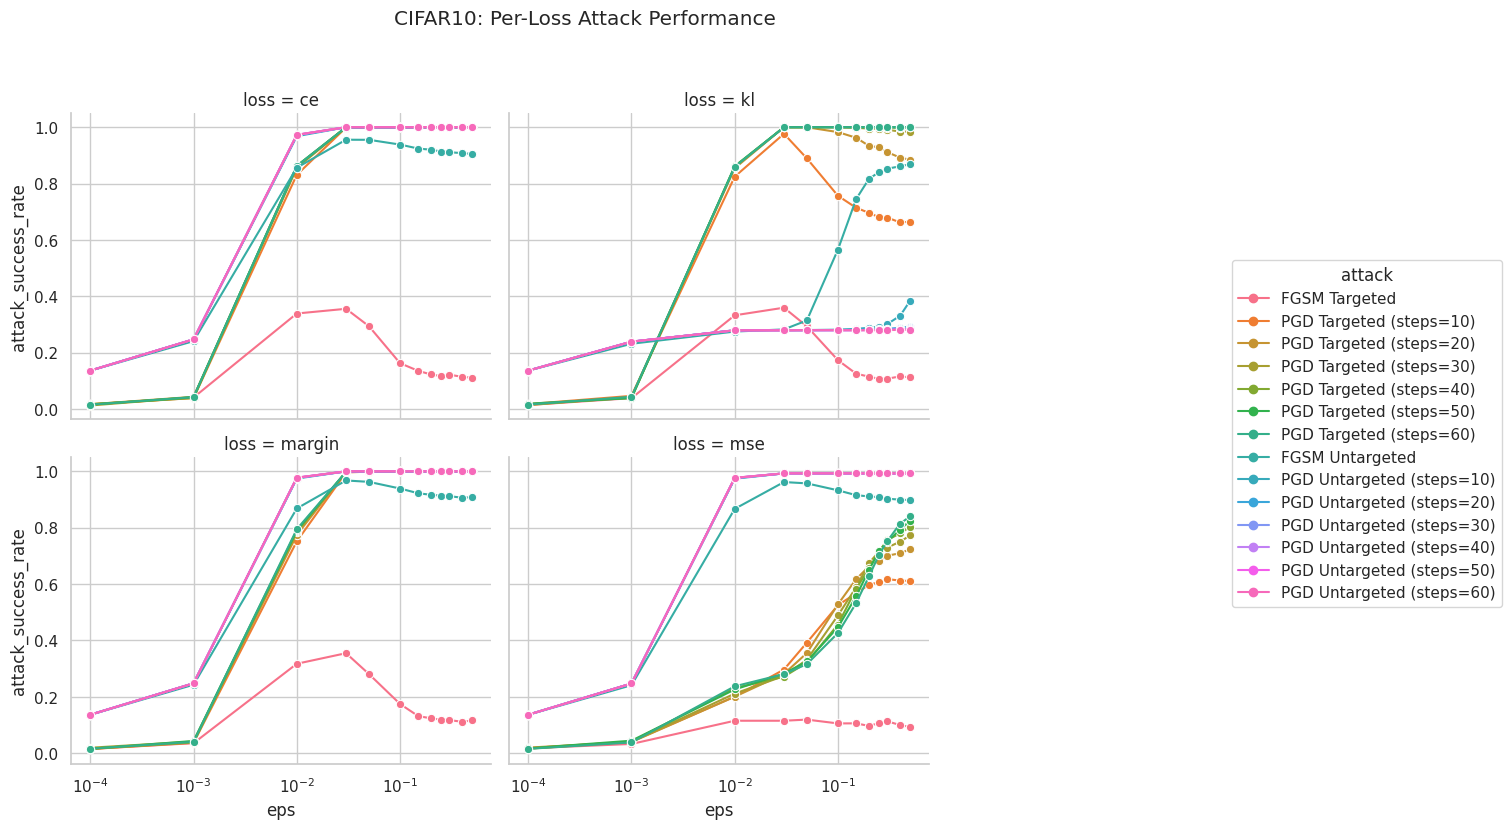

In [37]:
g = sns.relplot(
    data=cifar_df,
    x="eps",
    y="attack_success_rate",
    hue="attack",
    col="loss",
    kind="line",
    marker="o",
    col_wrap=2,
    height=4,
    aspect=1.2,
    legend="full"
)

g.set(xscale="log")
g.fig.suptitle("CIFAR10: Per-Loss Attack Performance", y=1.03)

sns.move_legend(
    g,
    "center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

g.fig.subplots_adjust(right=0.78, top=0.90)

plt.show()

#### CIFAR10: PGD Success Rate vs Iterations

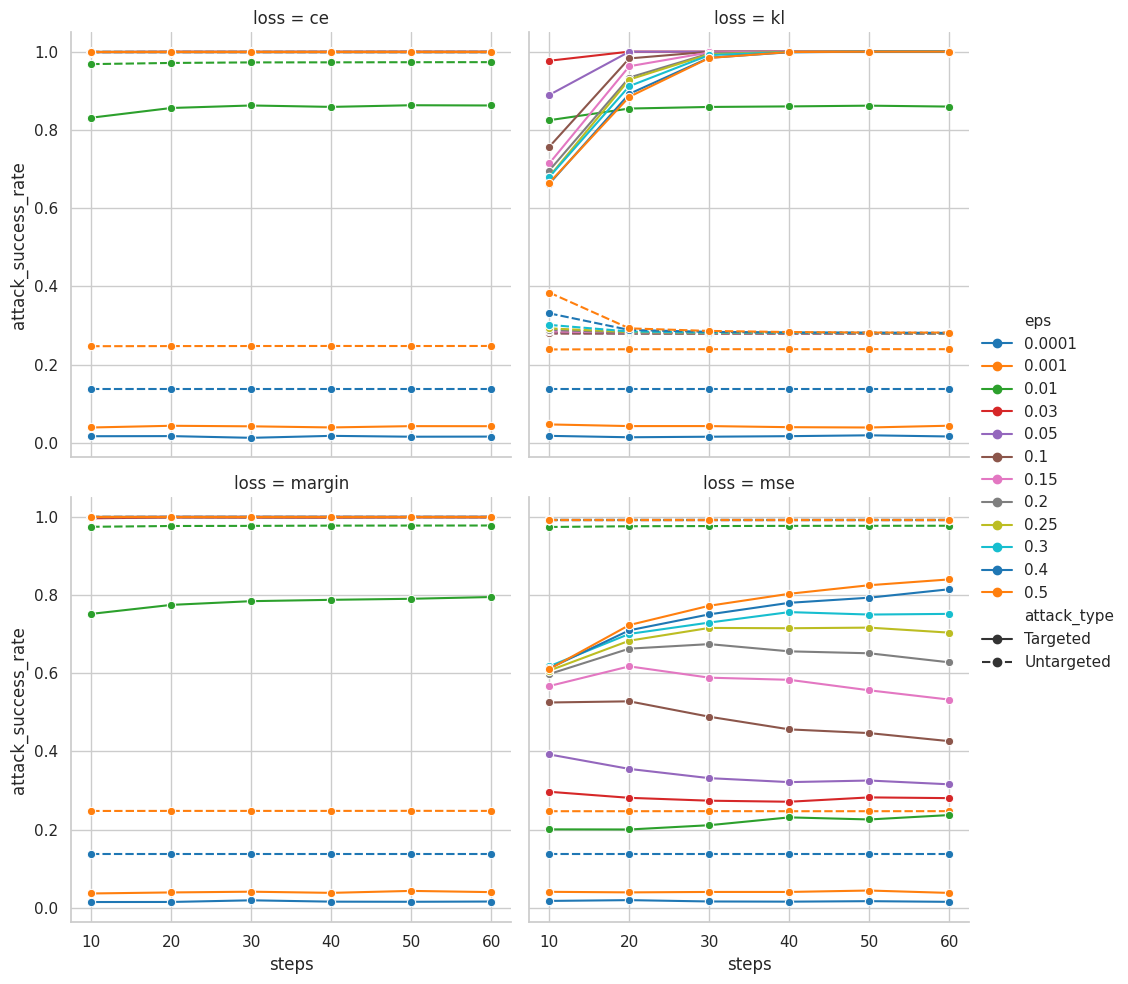

In [41]:
cifar_pgd_df = pgd_df[pgd_df["dataset"]=="cifar10"]

sns.relplot(
    data=cifar_pgd_df,
    x="steps",
    y="attack_success_rate",
    hue="eps",
    style="attack_type",
    col="loss",
    kind="line",
    marker="o",
    col_wrap=2,
    palette="tab10",
    legend="full"
)
plt.show()

#### CIFAR10: PGD Gain per Iteration

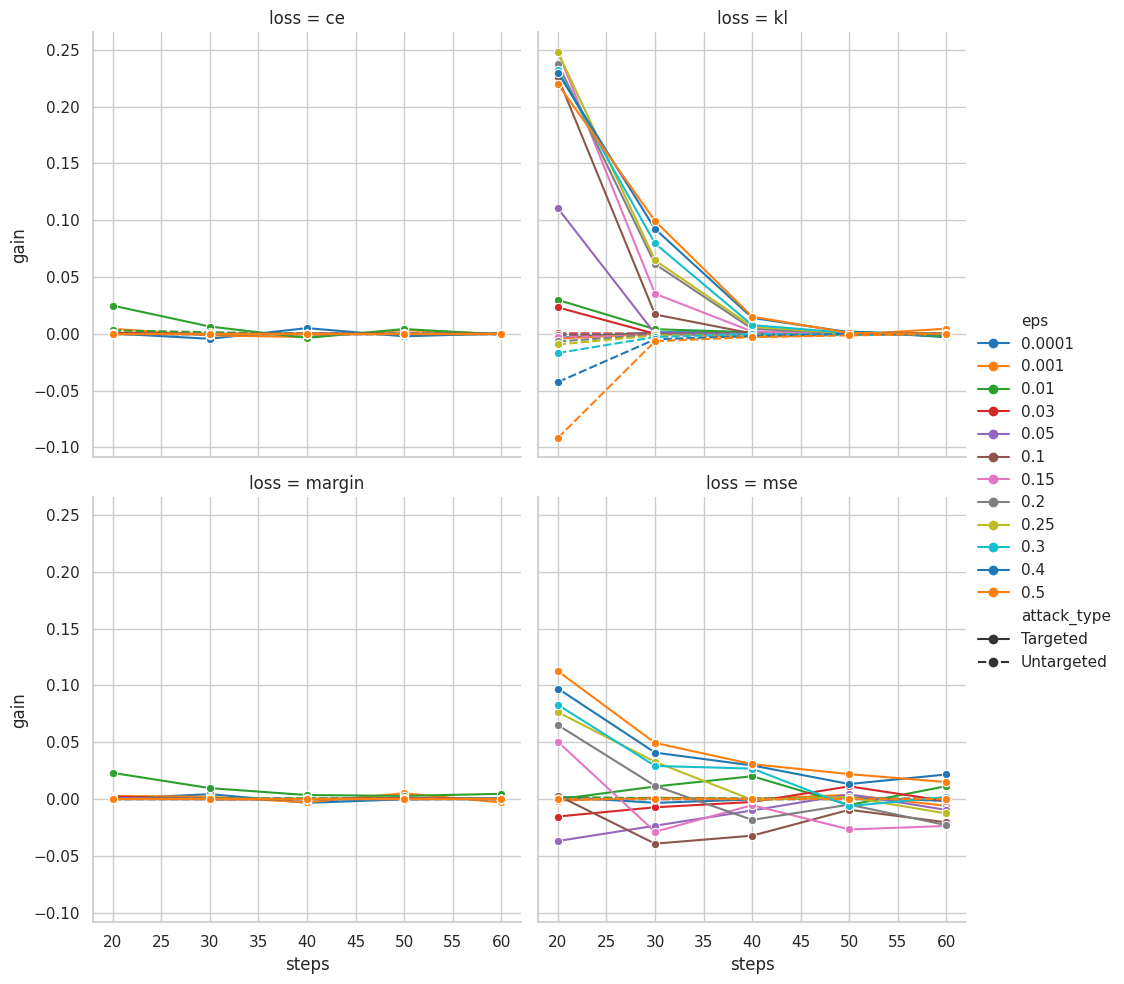

In [40]:
sns.relplot(
    data=cifar_pgd_df,
    x="steps",
    y="gain",
    hue="eps",
    style="attack_type",
    col="loss",
    kind="line",
    marker="o",
    col_wrap=2,
    palette="tab10",
    legend="full"
)
plt.show()

#### CIFAR10: PGD Efficiency

In [31]:
cifar_pgd_df

,dataset,loss,eps,attack,method,attack_type,steps,attack_success_rate,gain,efficiency,saturated
16,cifar10,ce,0.0001,PGD Targeted (steps=10),PGD,Targeted,10,0.016719,NaN,0.001672,False
18,cifar10,ce,0.0001,PGD Targeted (steps=20),PGD,Targeted,20,0.017031,0.000313,0.000852,True
20,cifar10,ce,0.0001,PGD Targeted (steps=30),PGD,Targeted,30,0.012656,-0.004375,0.000422,True
22,cifar10,ce,0.0001,PGD Targeted (steps=40),PGD,Targeted,40,0.017656,0.005000,0.000441,True
24,cifar10,ce,0.0001,PGD Targeted (steps=50),PGD,Targeted,50,0.015469,-0.002187,0.000309,True
...,...,...,...,...,...,...,...,...,...,...,...
1279,cifar10,mse,0.5000,PGD Untargeted (steps=20),PGD,Untargeted,20,0.992812,0.000000,0.049641,True
1281,cifar10,mse,0.5000,PGD Untargeted (steps=30),PGD,Untargeted,30,0.992812,0.000000,0.033094,True
1283,cifar10,mse,0.5000,PGD Untargeted (steps=40),PGD,Untargeted,40,0.992812,0.000000,0.024820,True
1285,cifar10,mse,0.5000,PGD Untargeted (steps=50),PGD,Untargeted,50,0.992812,0.000000,0.019856,True


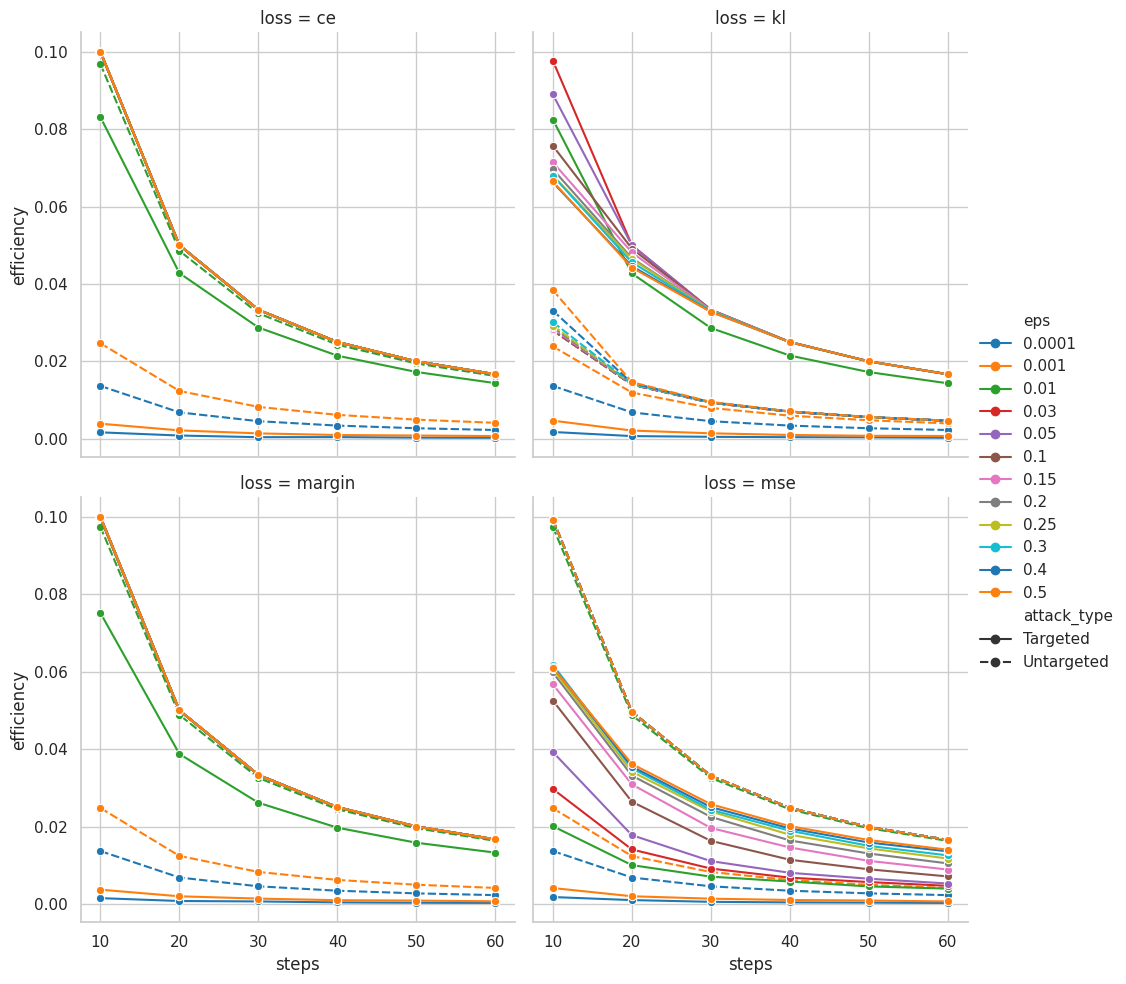

In [39]:
sns.relplot(
    data=cifar_pgd_df,
    x="steps",
    y="efficiency",
    hue="eps",
    style="attack_type",
    col="loss",
    kind="line",
    marker="o",
    col_wrap=2,
    palette="tab10",
    legend="full"
)
plt.show()

#### CIFAR10: Saturation Point Analysis

In [23]:
cifar_sat = cifar_pgd_df[cifar_pgd_df["saturated"]==True]

cifar_sat.groupby(["loss","attack_type","eps"])["steps"].min().reset_index()

,loss,attack_type,eps,steps
0,ce,Targeted,0.0001,20
1,ce,Targeted,0.0010,20
2,ce,Targeted,0.0100,30
3,ce,Targeted,0.0300,20
4,ce,Targeted,0.0500,20
...,...,...,...,...
89,mse,Untargeted,0.2000,20
90,mse,Untargeted,0.2500,20
91,mse,Untargeted,0.3000,20
92,mse,Untargeted,0.4000,20


#### CIFAR10: Gradient Magnitude

Files already downloaded and verified


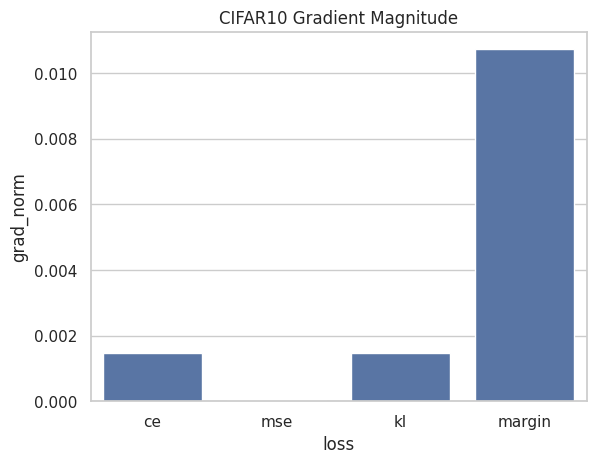

In [24]:
dataset, model = get_dataset_and_model("CIFAR10")
loader = DataLoader(dataset, batch_size=128)

results = []

for loss in ["ce","mse","kl","margin"]:
    vals = []

    for x,y in loader:
        x,y = x.to(device), y.to(device)
        model.zero_grad()
        vals.append(compute_gradient_norm(model,x,y,loss))

    results.append({
        "loss":loss,
        "grad_norm":sum(vals)/len(vals)
    })

cifar_grad_df = pd.DataFrame(results)

sns.barplot(data=cifar_grad_df, x="loss", y="grad_norm")
plt.title("CIFAR10 Gradient Magnitude")
plt.show()